In [243]:
### Importing the necessary libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import math

### loading the dataset 

In [244]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Check number of rows and columns 

In [245]:
df.shape

(10000, 14)

### Get column names,data types,and null values 

In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### Statistical summary for numerical columns

In [247]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Viwe all column names 

In [248]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [249]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### identify duplicate rows in each columns

In [250]:
df.duplicated().sum()

np.int64(0)

### Checking the correlation between the columns

In [251]:
df.corr(numeric_only =True)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


### Checking Outliers 

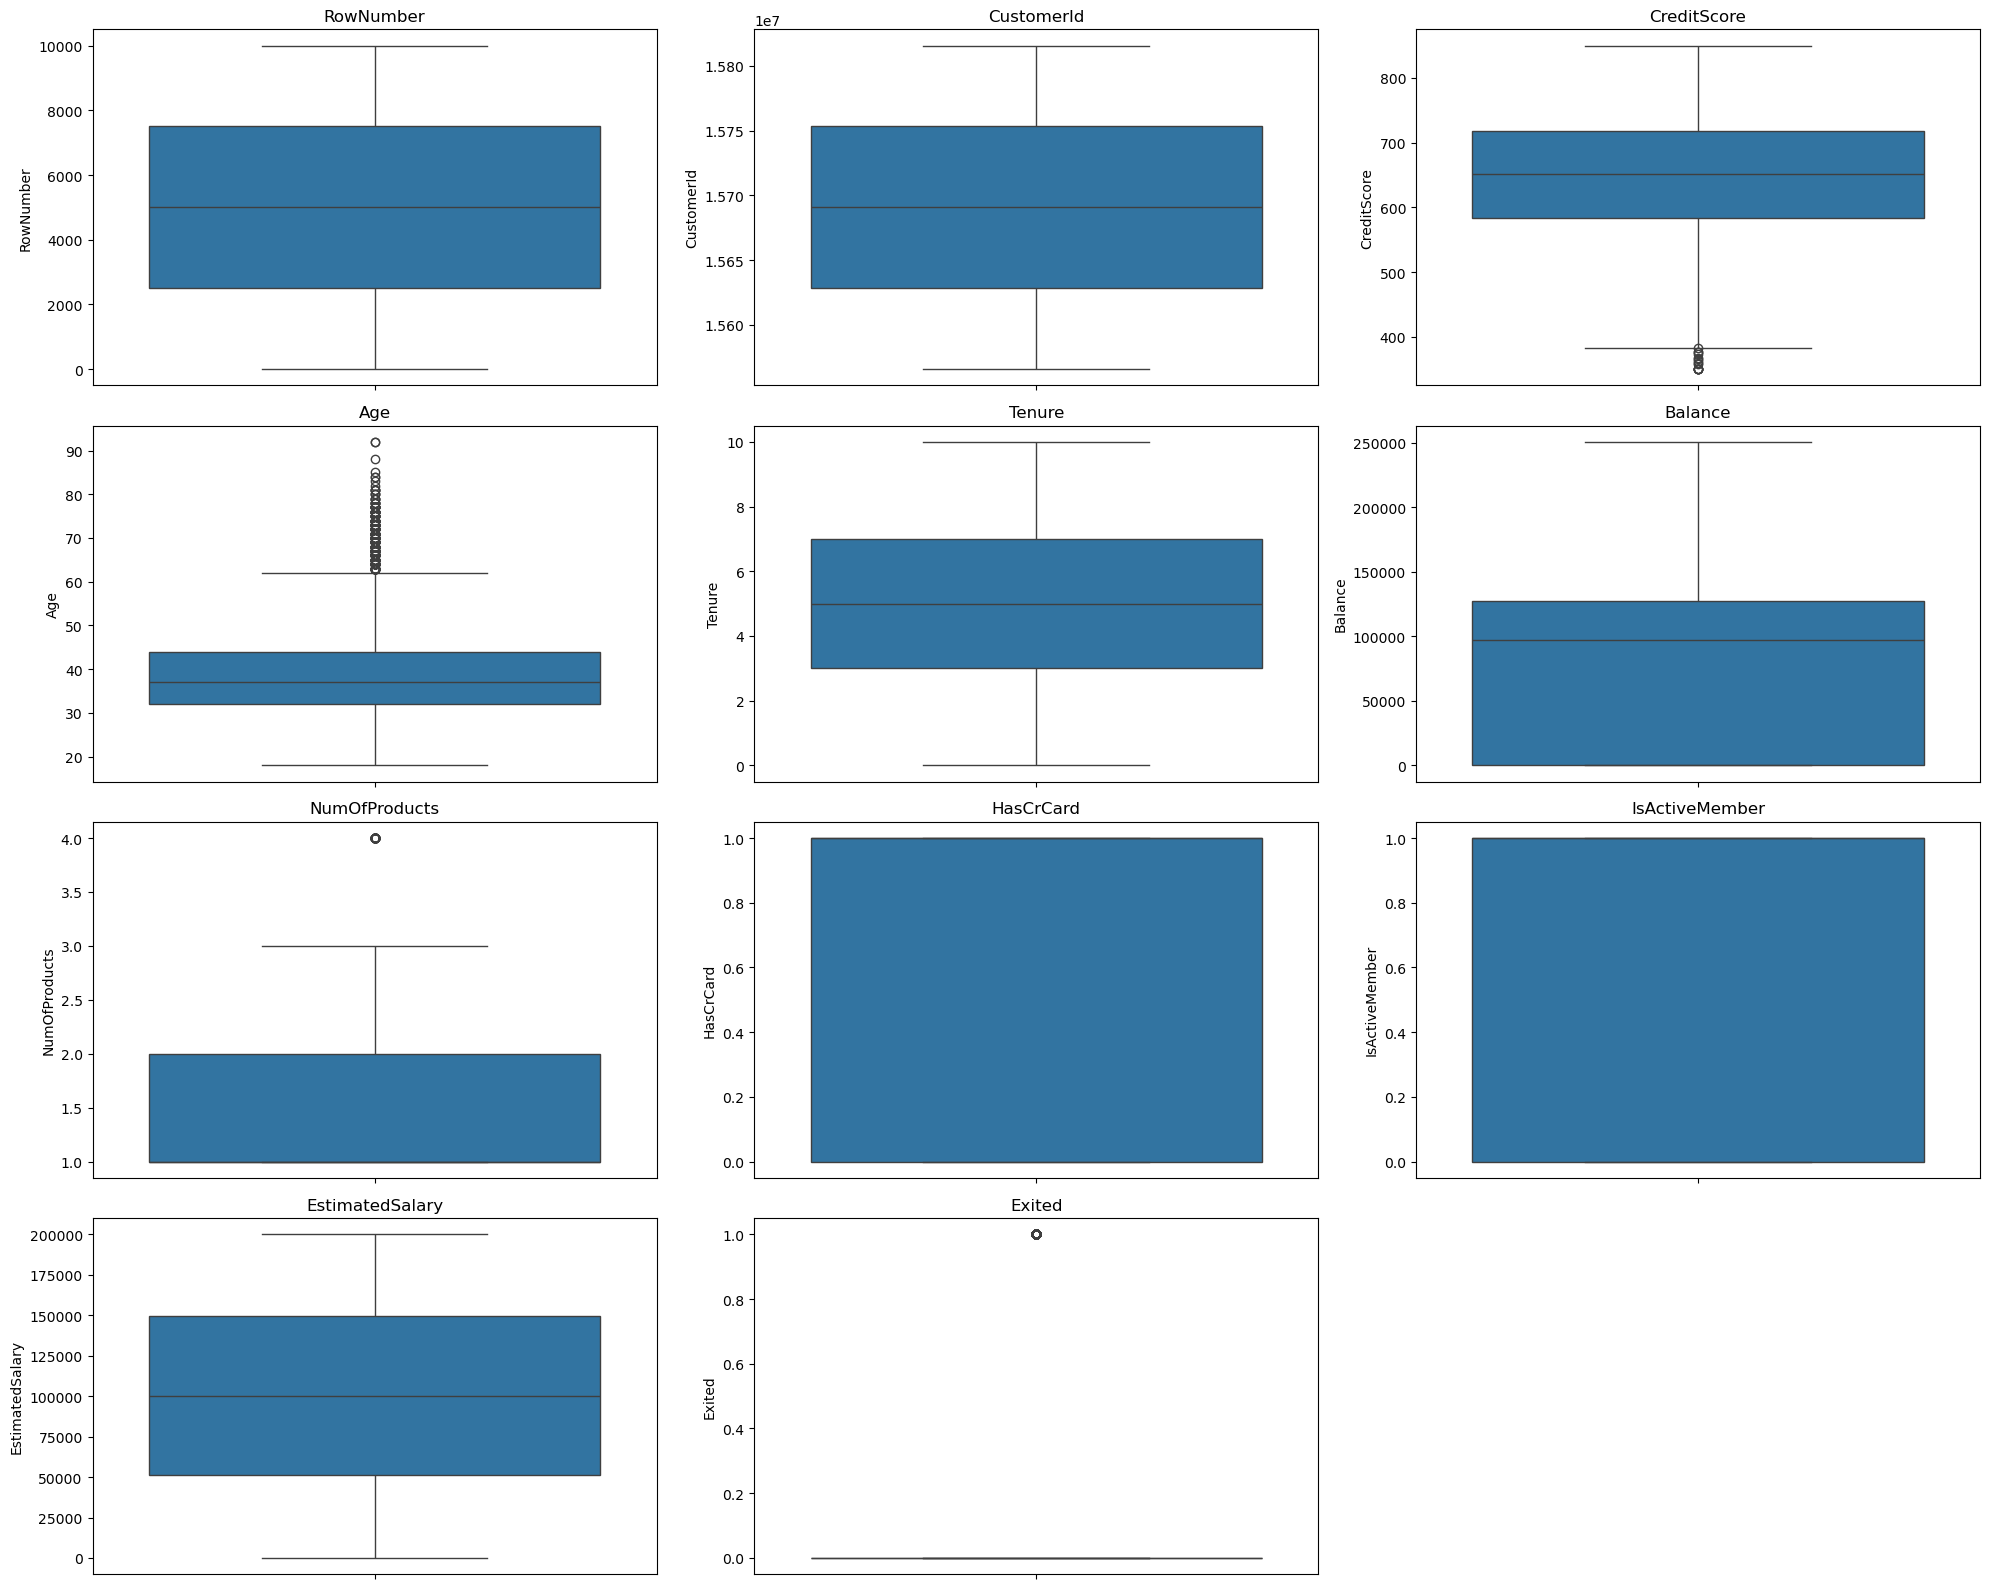

In [252]:
num_cols = df.select_dtypes(include='number').columns

rows = math.ceil(len(num_cols) / 3)

plt.figure(figsize=(20, rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Univariate Analysis

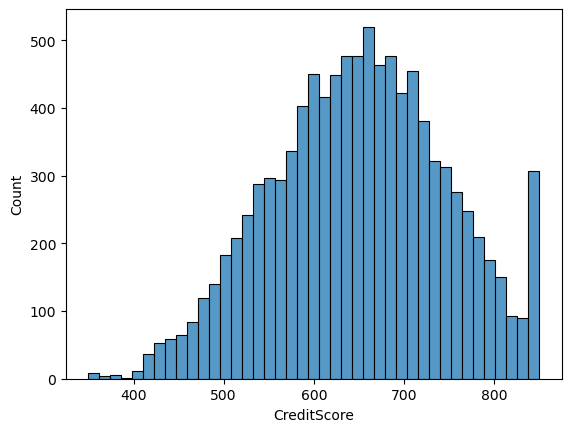

In [253]:
sns.histplot(df['CreditScore'])
plt.show()

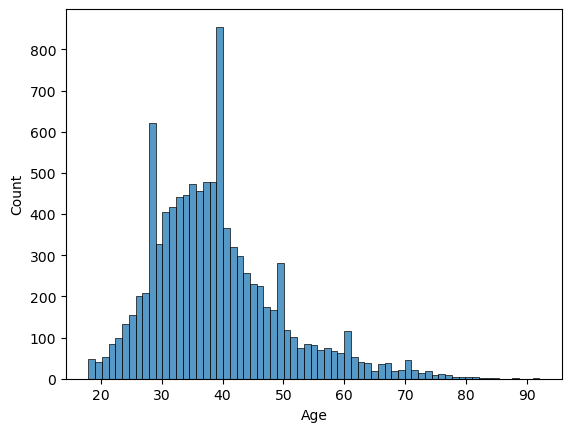

In [254]:
sns.histplot(df['Age'])
plt.show()

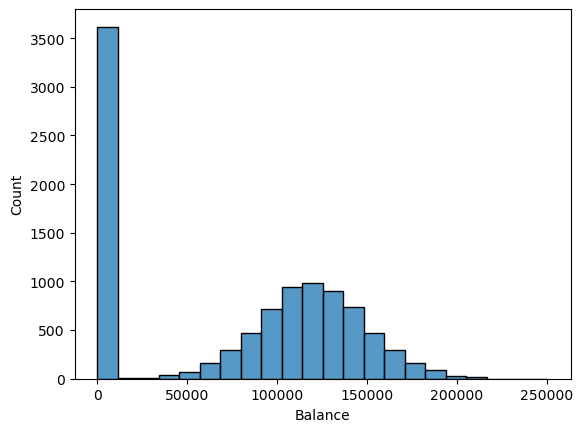

In [255]:
sns.histplot(df['Balance'])
plt.show()

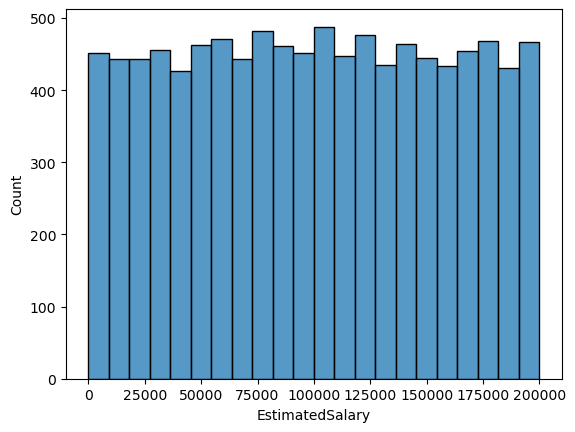

In [256]:
sns.histplot(df['EstimatedSalary'])
plt.show()

<Axes: xlabel='Geography', ylabel='count'>

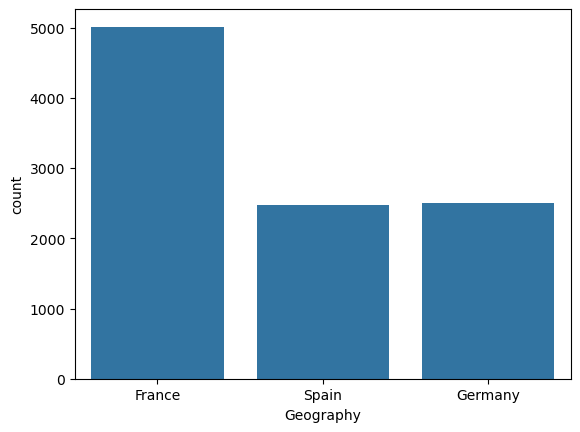

In [257]:
sns.countplot(x=df['Geography'])

<Axes: xlabel='Gender', ylabel='count'>

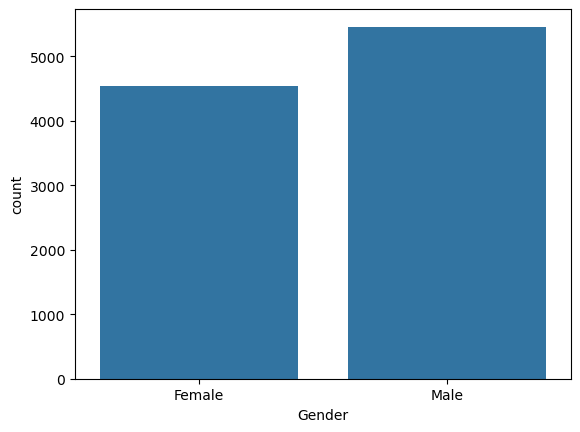

In [258]:
sns.countplot(x=df['Gender'])

<Axes: xlabel='Tenure', ylabel='count'>

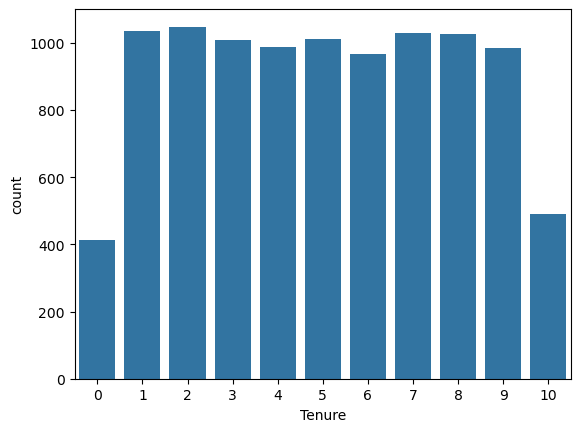

In [259]:
sns.countplot(x=df['Tenure'])

<Axes: xlabel='NumOfProducts', ylabel='count'>

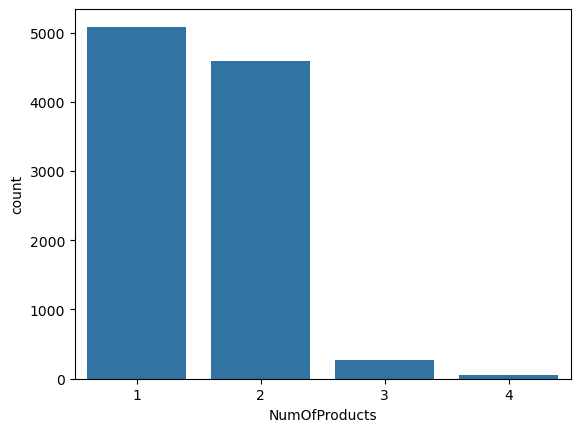

In [260]:
sns.countplot(x=df['NumOfProducts'])

<Axes: xlabel='HasCrCard', ylabel='count'>

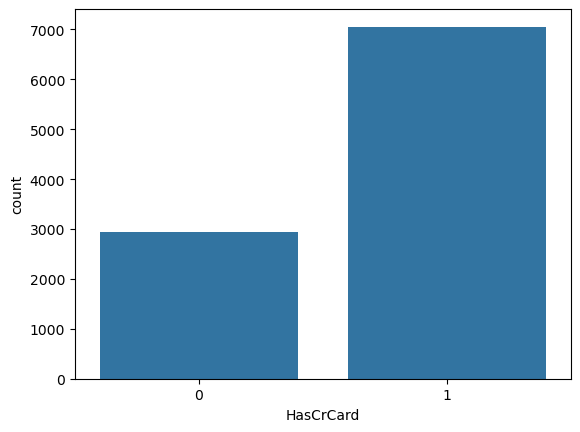

In [261]:
sns.countplot(x=df['HasCrCard'])

<Axes: xlabel='IsActiveMember', ylabel='count'>

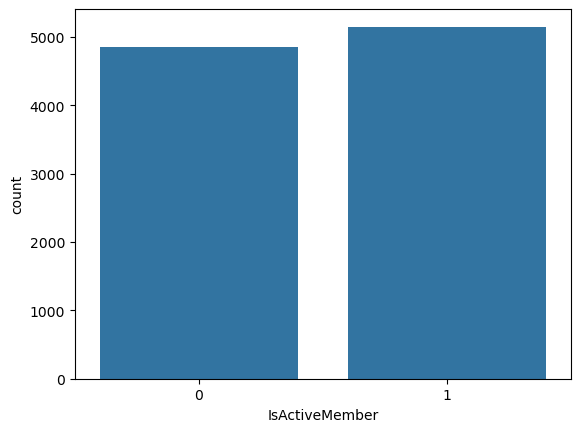

In [262]:
sns.countplot(x=df['IsActiveMember'])

<Axes: xlabel='Exited', ylabel='count'>

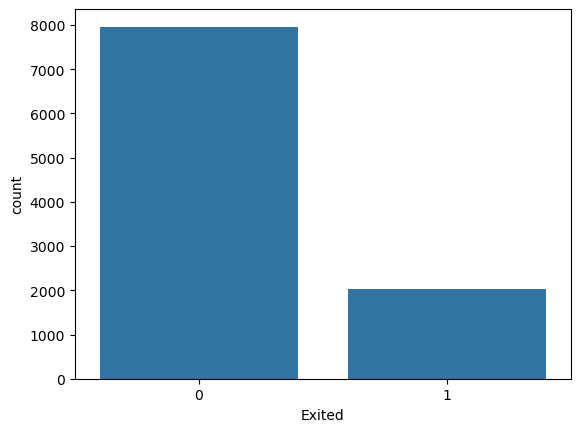

In [263]:
sns.countplot(x=df['Exited'])

### Bivariate Analysis

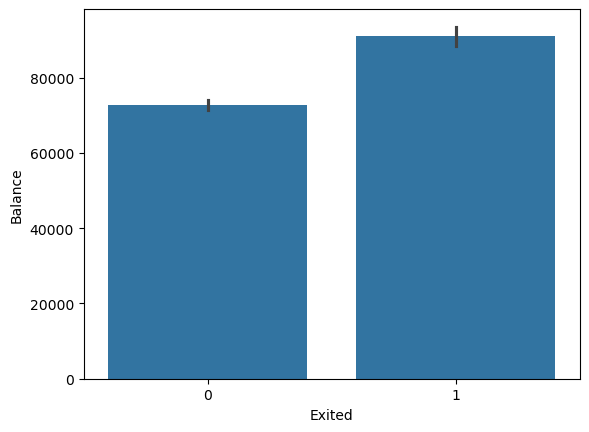

In [264]:
sns.barplot(data=df,
            x='Exited',
            y='Balance')

plt.show()

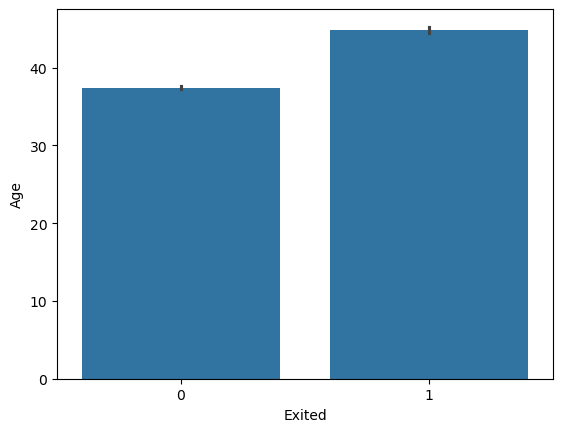

In [265]:

sns.barplot(data=df,
                x='Exited',
                y='Age')
plt.show()

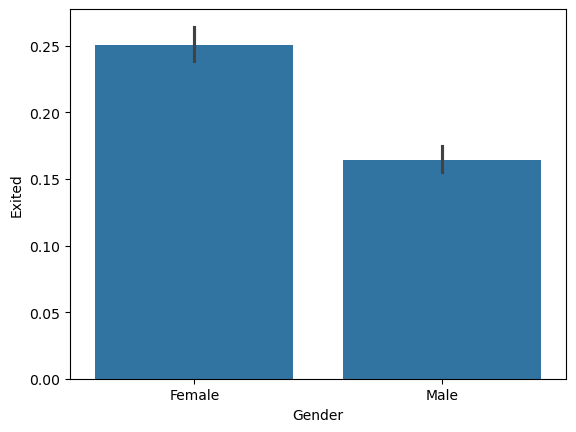

In [266]:
sns.barplot(data=df,
              x='Gender',
              y='Exited')

plt.show()

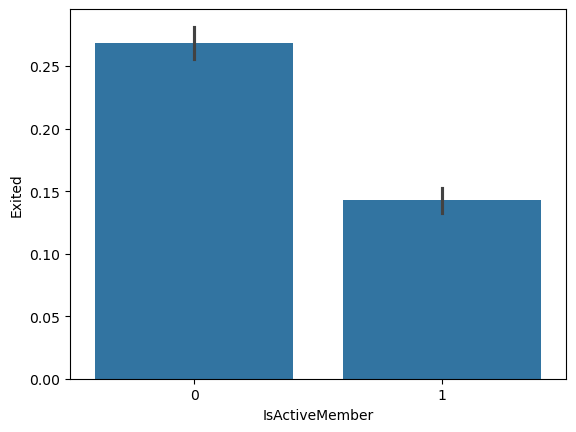

In [267]:
sns.barplot(data=df,
                x='IsActiveMember',
                y='Exited')
plt.show()

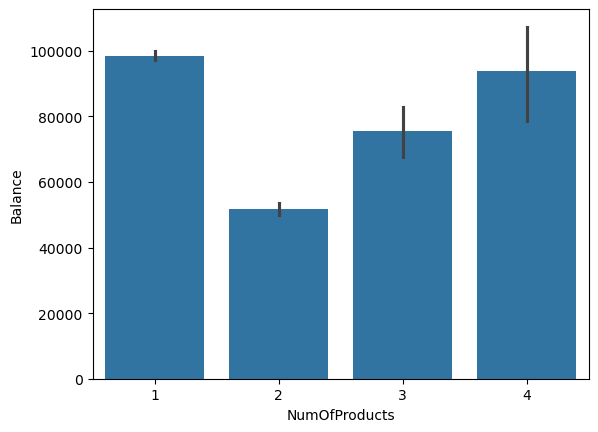

In [268]:
sns.barplot(data=df,
                x='NumOfProducts',
                y='Balance')
plt.show()

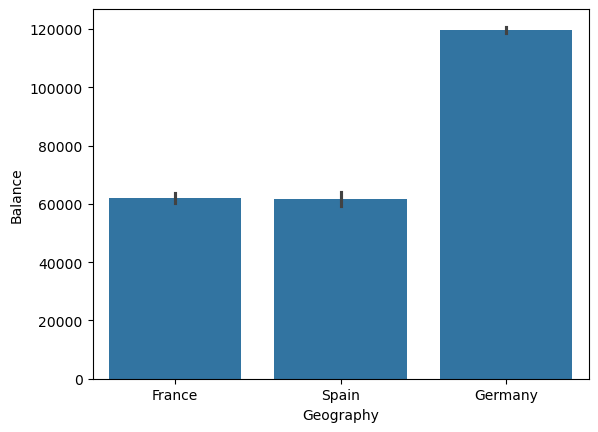

In [269]:
sns.barplot(data=df,
                x='Geography',
                y='Balance')
plt.show()

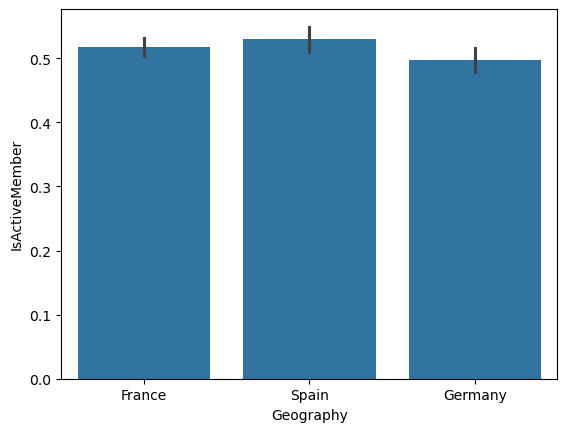

In [270]:
sns.barplot(data=df,
                y='IsActiveMember',
                x='Geography')
plt.show()

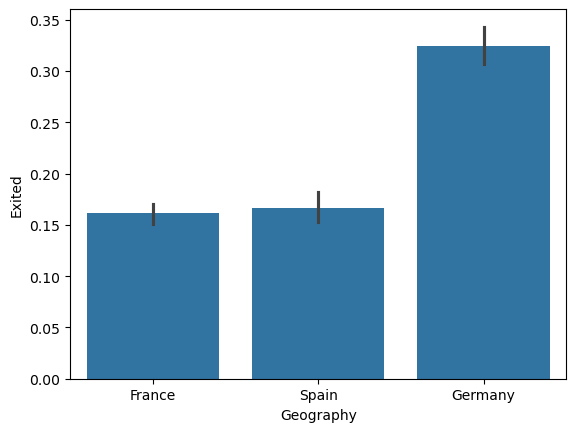

In [271]:
sns.barplot(data=df,
                y='Exited',
                x='Geography')
plt.show()

### Multivariate Analysis

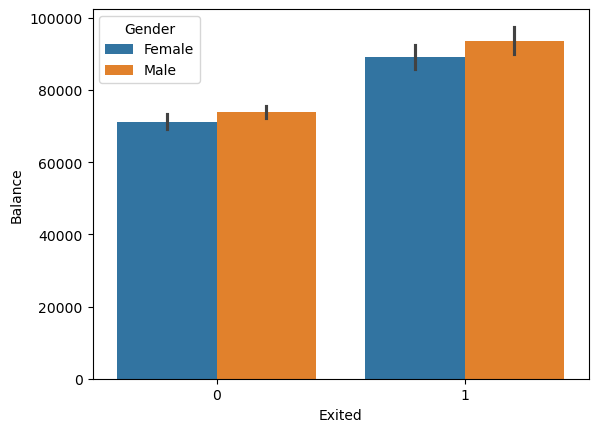

In [272]:
sns.barplot(data=df,
                y='Balance',
                x='Exited',
           hue ='Gender')
plt.show()

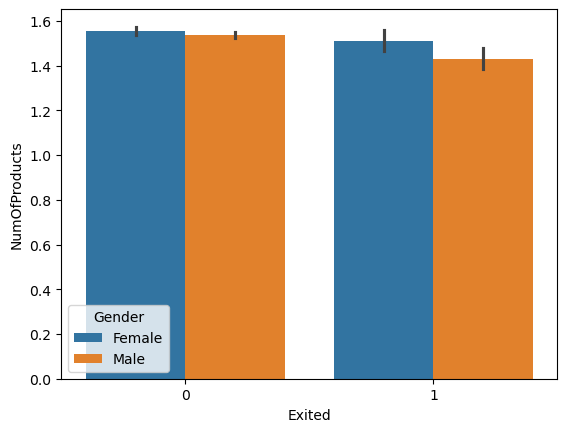

In [273]:
sns.barplot(data=df,
                y='NumOfProducts',
                x='Exited',
           hue ='Gender')
plt.show()

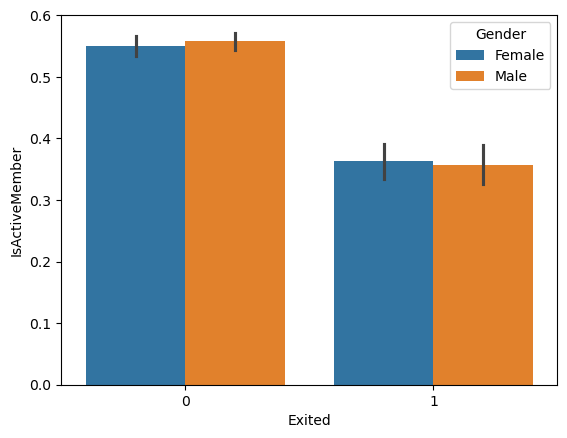

In [274]:
sns.barplot(data=df,
                y='IsActiveMember',
                x='Exited',
           hue ='Gender')
plt.show()

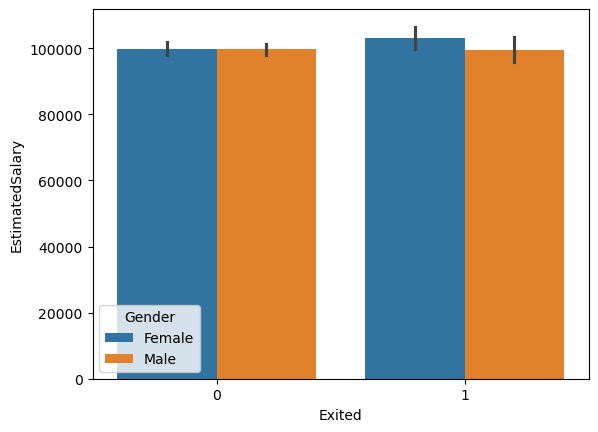

In [275]:
sns.barplot(data=df,
                y='EstimatedSalary',
                x='Exited',
           hue ='Gender')
plt.show()

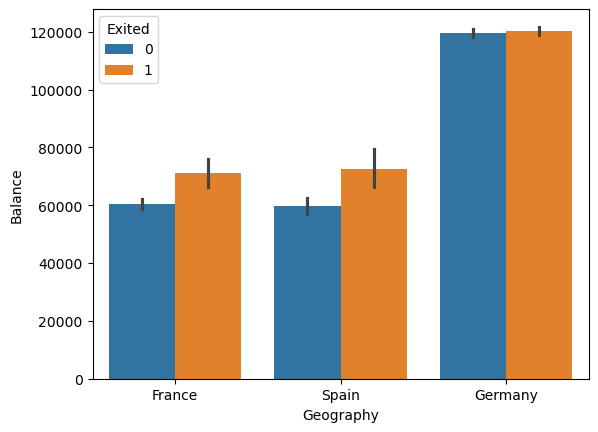

In [276]:
sns.barplot(data=df,
                y='Balance',
                hue='Exited',
           x='Geography')
plt.show()

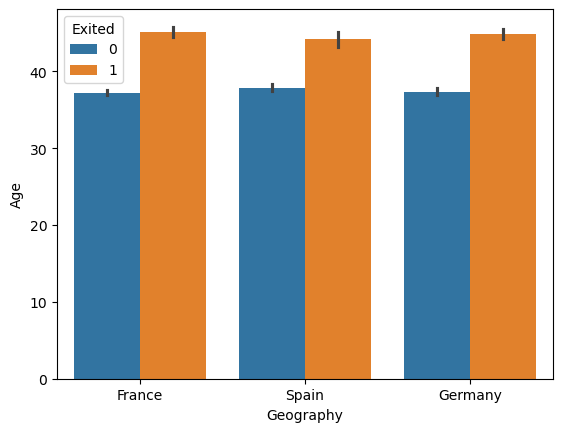

In [277]:
sns.barplot(data=df,
                y='Age',
                hue='Exited',
           x='Geography')
plt.show()

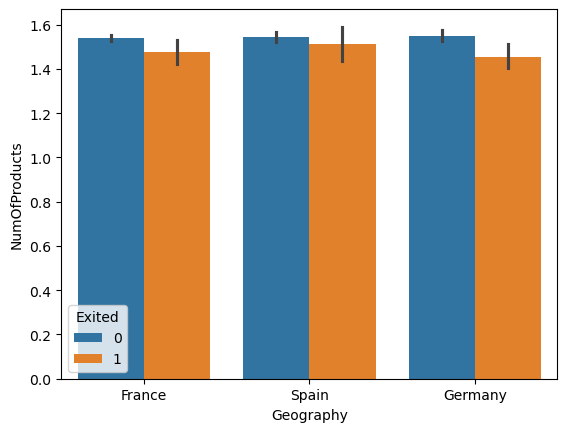

In [278]:
sns.barplot(data=df,
                y='NumOfProducts',
                hue='Exited',
           x='Geography')
plt.show()

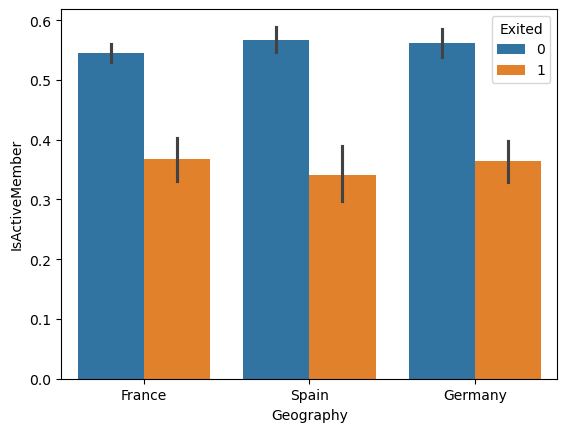

In [279]:
sns.barplot(data=df,
                y='IsActiveMember',
                hue='Exited',
           x='Geography')
plt.show()

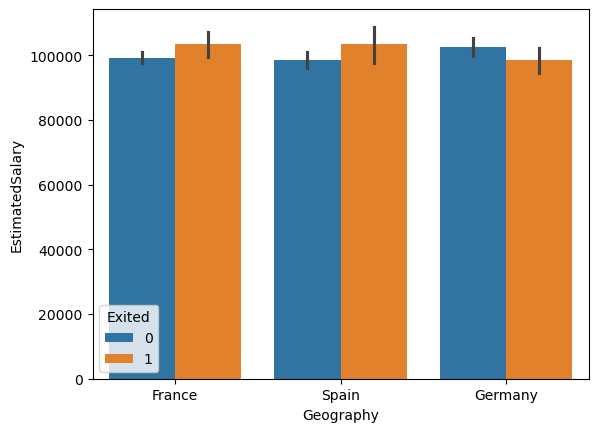

In [280]:
sns.barplot(data=df,
                y='EstimatedSalary',
                hue='Exited',
           x='Geography')
plt.show()

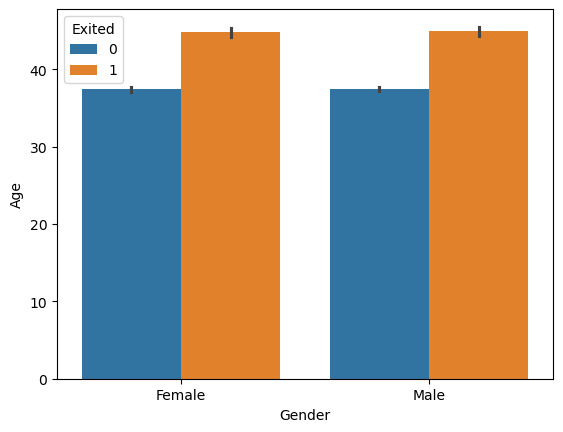

In [281]:
sns.barplot(data=df,
                y='Age',
                hue='Exited',
           x='Gender')
plt.show()

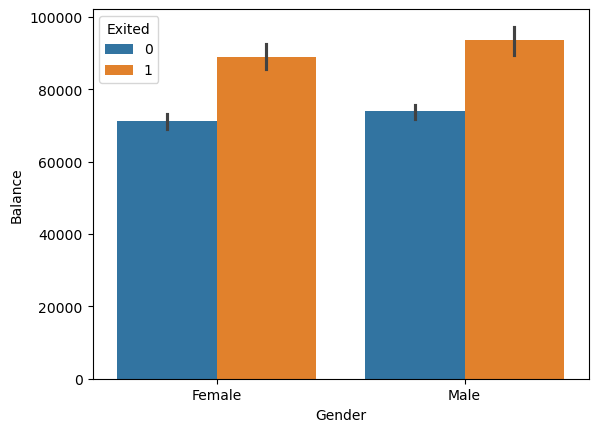

In [282]:
sns.barplot(data=df,
                y='Balance',
                hue='Exited',
           x='Gender')
plt.show()

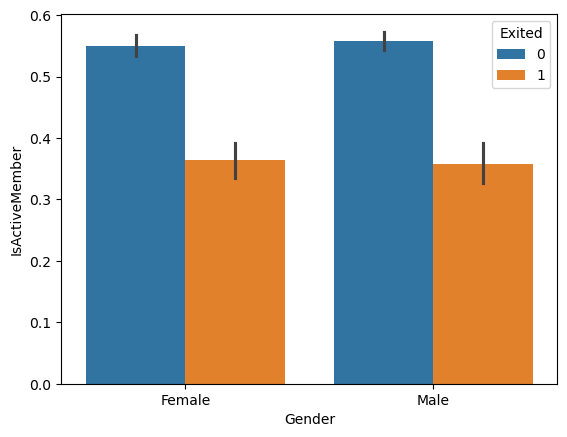

In [283]:
sns.barplot(data=df,
                y='IsActiveMember',
                hue='Exited',
           x='Gender')
plt.show()

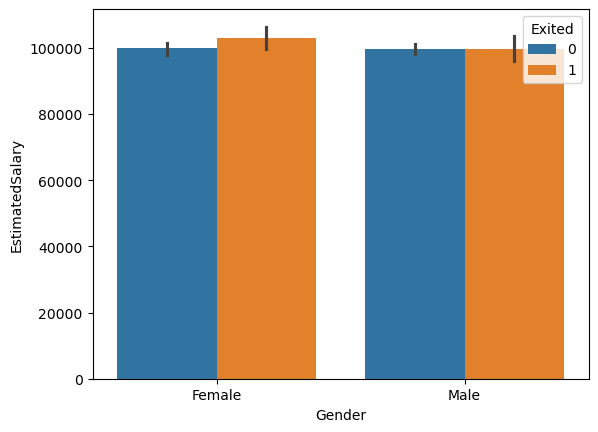

In [284]:
sns.barplot(data=df,
                y='EstimatedSalary',
                hue='Exited',
           x='Gender')
plt.show()

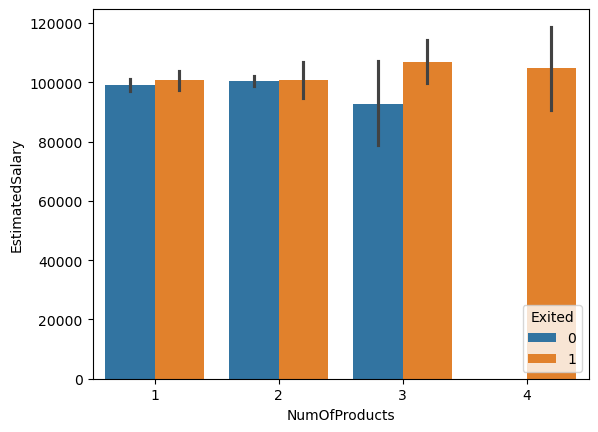

In [285]:
sns.barplot(data=df,
                y='EstimatedSalary',
                hue='Exited',
           x='NumOfProducts')
plt.show()

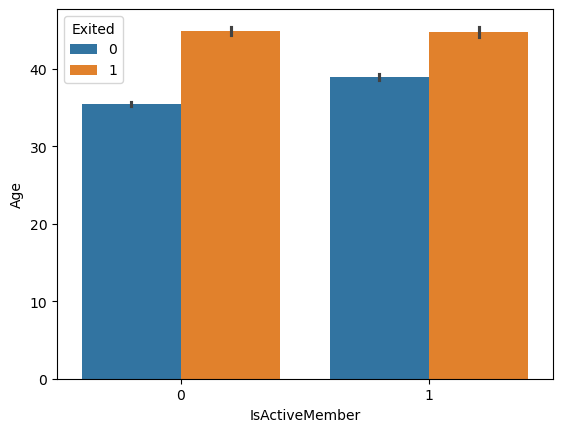

In [286]:
sns.barplot(data=df,
                y='Age',
                hue='Exited',
           x='IsActiveMember')
plt.show()

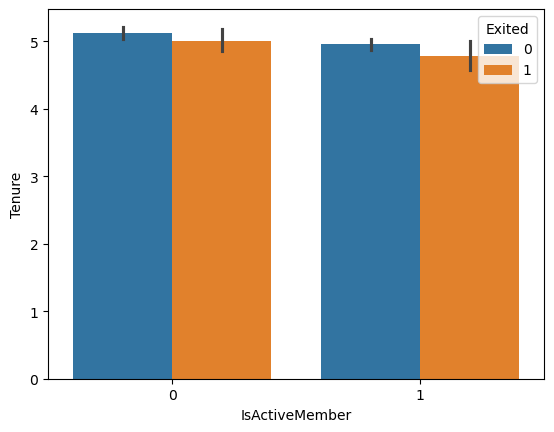

In [287]:
sns.barplot(data=df,
                y='Tenure',
                hue='Exited',
           x='IsActiveMember')
plt.show()

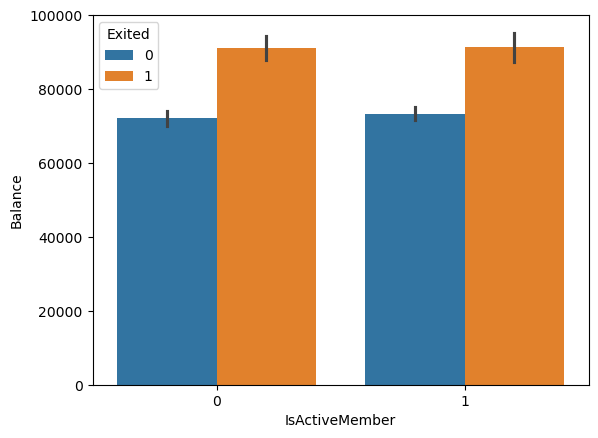

In [288]:
sns.barplot(data=df,
                y='Balance',
                hue='Exited',
           x='IsActiveMember')
plt.show()

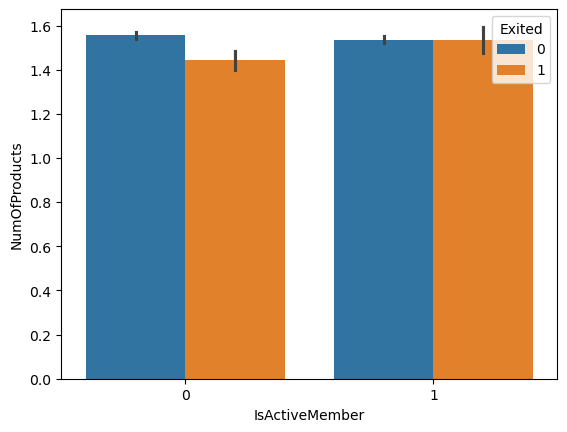

In [289]:
sns.barplot(data=df,
                y='NumOfProducts',
                hue='Exited',
           x='IsActiveMember')
plt.show()

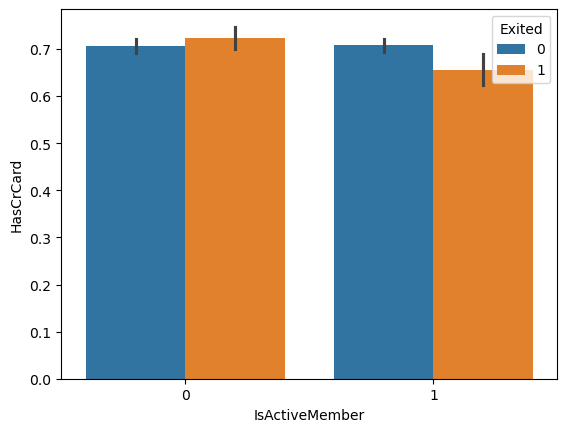

In [290]:
sns.barplot(data=df,
                y='HasCrCard',
                hue='Exited',
           x='IsActiveMember')
plt.show()

In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [292]:
df["Exited"] = df["Exited"].astype(bool)

print(df.dtypes)

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited                bool
dtype: object


In [293]:
#Checking Outliyers
num_cols = df.select_dtypes(include=['int64', 'float64']).columns


for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 40)

RowNumber
Number of Outliers: 0
----------------------------------------
CustomerId
Number of Outliers: 0
----------------------------------------
CreditScore
Number of Outliers: 15
----------------------------------------
Age
Number of Outliers: 359
----------------------------------------
Tenure
Number of Outliers: 0
----------------------------------------
Balance
Number of Outliers: 0
----------------------------------------
NumOfProducts
Number of Outliers: 60
----------------------------------------
HasCrCard
Number of Outliers: 0
----------------------------------------
IsActiveMember
Number of Outliers: 0
----------------------------------------
EstimatedSalary
Number of Outliers: 0
----------------------------------------


In [302]:
# Remove Outliers from the Original DataFrame

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

original_shape = df.shape

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Delete outlier rows from the original DataFrame
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Original Shape :", original_shape)
print("New Shape      :", df.shape)
print("Rows Removed   :", original_shape[0] - df.shape[0])

Original Shape : (10000, 14)
New Shape      : (9568, 14)
Rows Removed   : 432


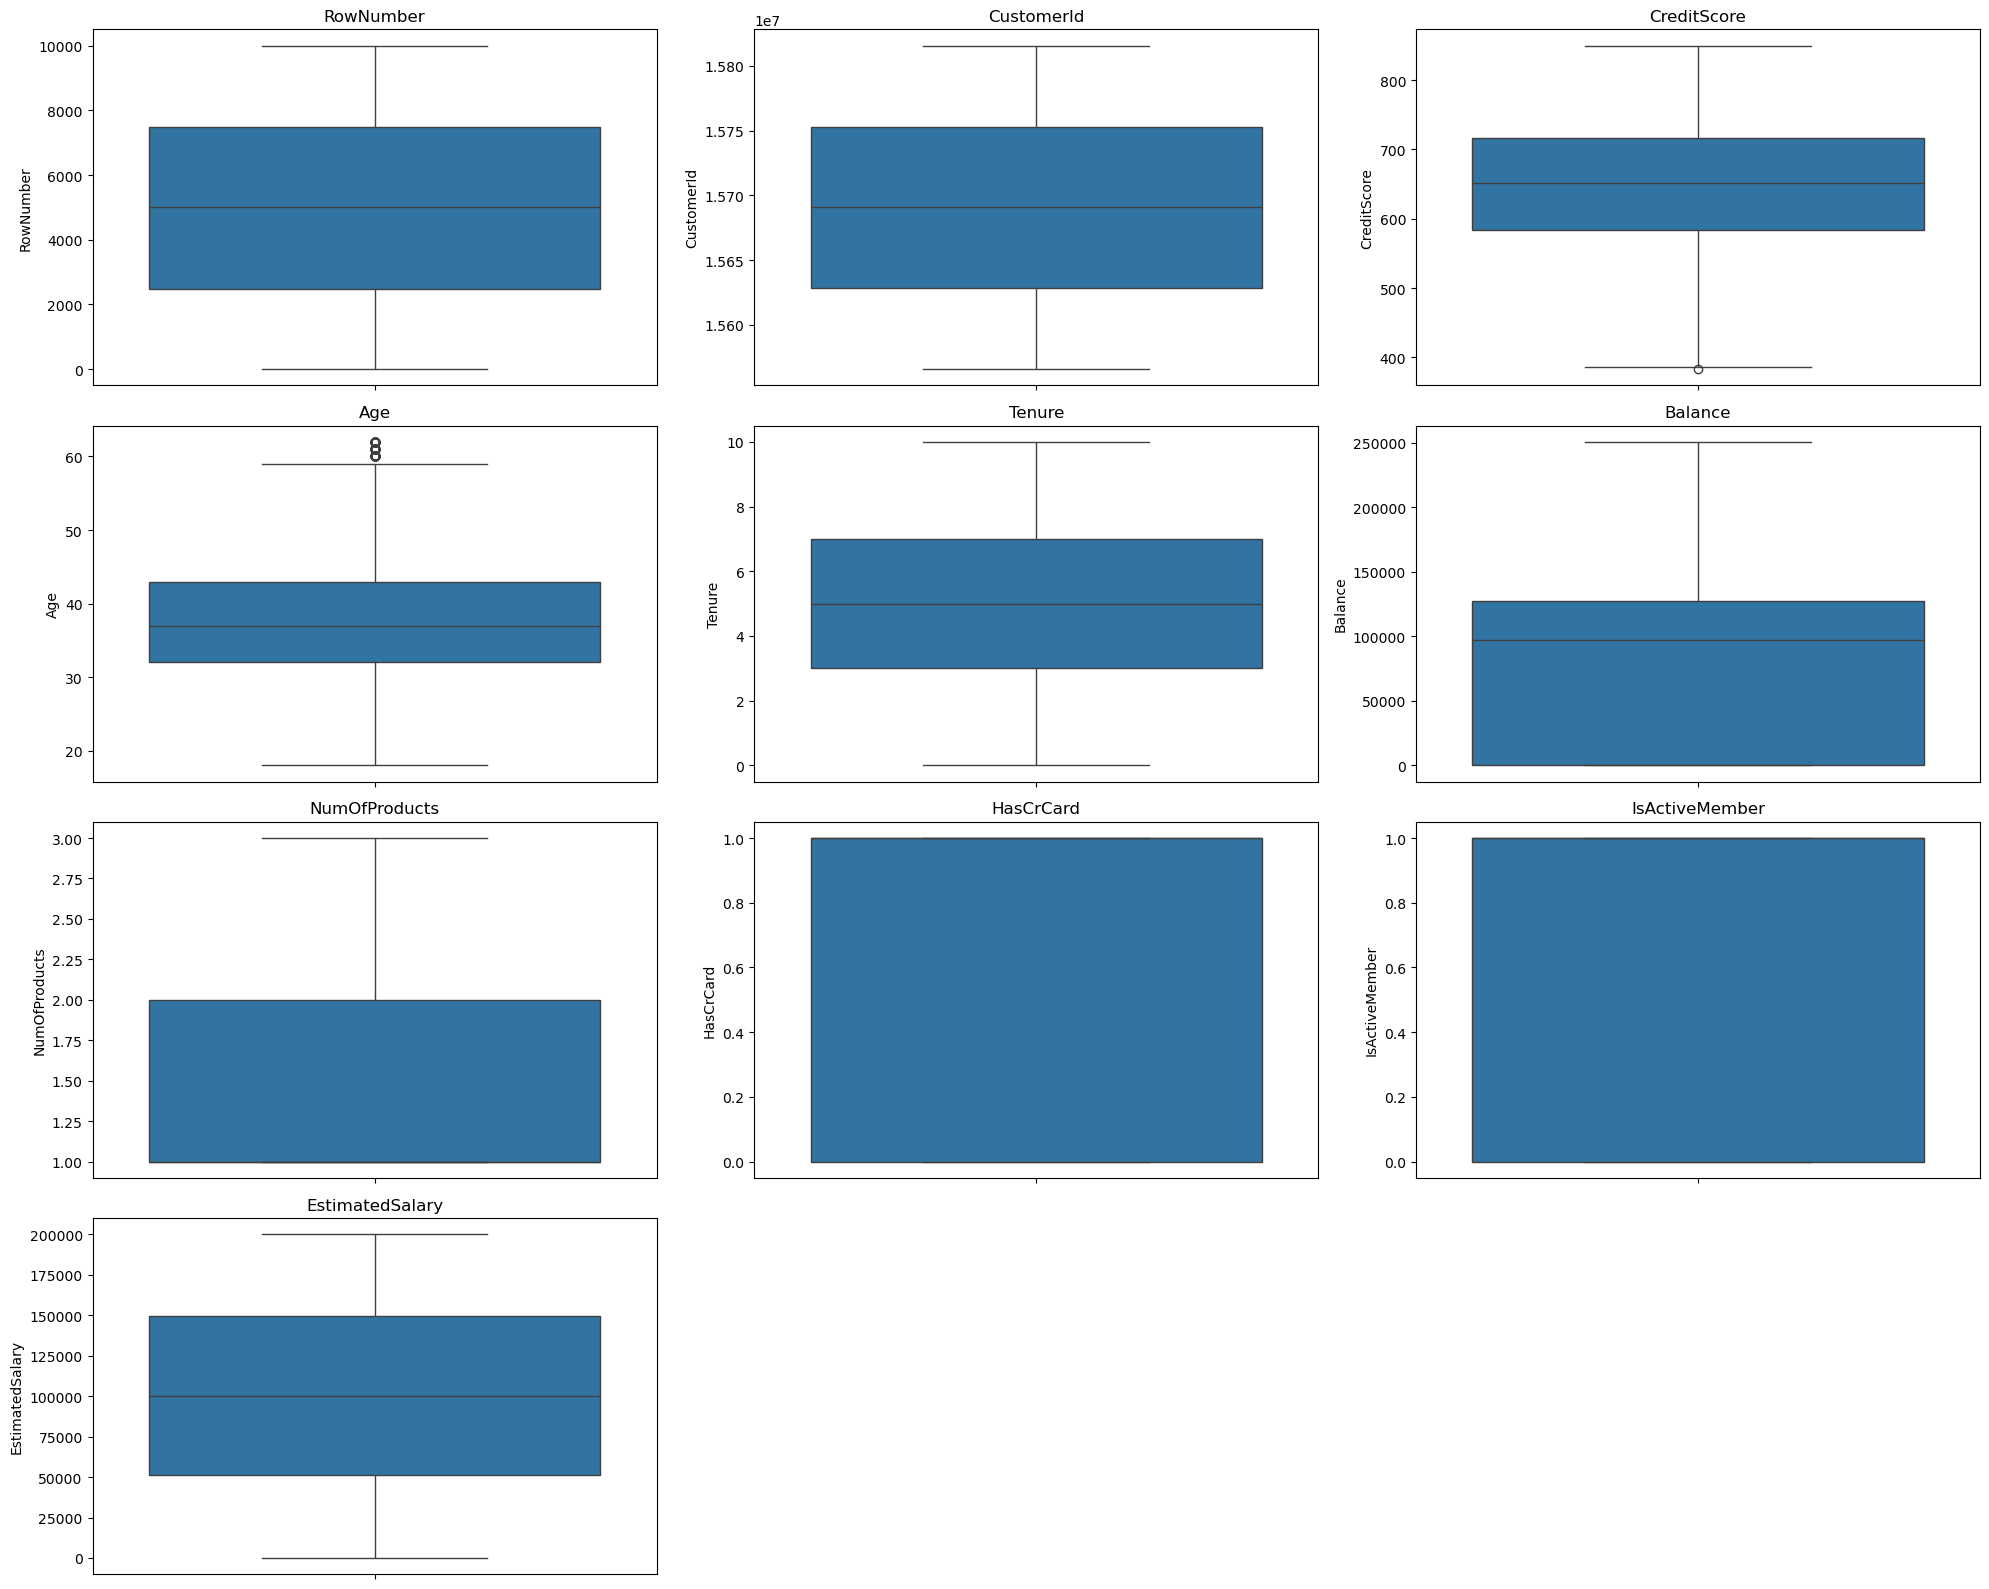

In [303]:
num_cols = df.select_dtypes(include='number').columns

rows = math.ceil(len(num_cols) / 3)

plt.figure(figsize=(20, rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [304]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,True
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,False
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,True
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,False
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,False


In [305]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [307]:
df["Exited"] = df["Exited"].astype(int)

print(df.dtypes)

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [308]:
df.to_csv("Clean_Churan.csv")